## This miniproject will show some experiment with MCMC and Linear Regression 

In [19]:
import pandas as pd 
import numpy as np
import scipy
import matplotlib.pyplot as plt 

### Part 1: Experiment when scaling a pdf function by a constant 

In [18]:
import copy 
# The code below implement MCMC with Metropolis-Hasting algorithm for the next state transition

class AcceptanceTracker(object):
    def __init__(self):
        self.__accept_count = 0
        self.__total_count = 0 

    def record(self, cur_state, next_state):
        if cur_state is not next_state: 
            self.__accept_count += 1

        self.__total_count += 1 

    def reset(self):
        self.__accept_count = 0
        self.__total_count = 0 

    def get_acceptance_rate(self):
        return self.__accept_count / self.__total_count 


def mcmc(initial_state, log_pdf_fn, proposed_fn, iters = 10000, tracker = None):
    state_list = [initial_state]
    reject_count = 0 
    for _ in range(iters):
        cur_state = state_list[-1] 
        proposed_state = proposed_fn(cur_state)
        log_diff = min(log_pdf_fn(proposed_state) - log_pdf_fn(cur_state), 0)
        next_state = proposed_state if (log_diff > np.log(np.random.uniform(0, 1))) else cur_state 
        if tracker: 
            tracker.record(cur_state, next_state)
        
        state_list.append(copy.deepcopy(next_state))

    return state_list 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_28200/1566217598.py:29: RuntimeWarning: invalid value encountered in scalar subtract
  log_diff = min(log_pdf_fn(proposed_state) - log_pdf_fn(cur_state), 0)
/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_28200/194311265.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


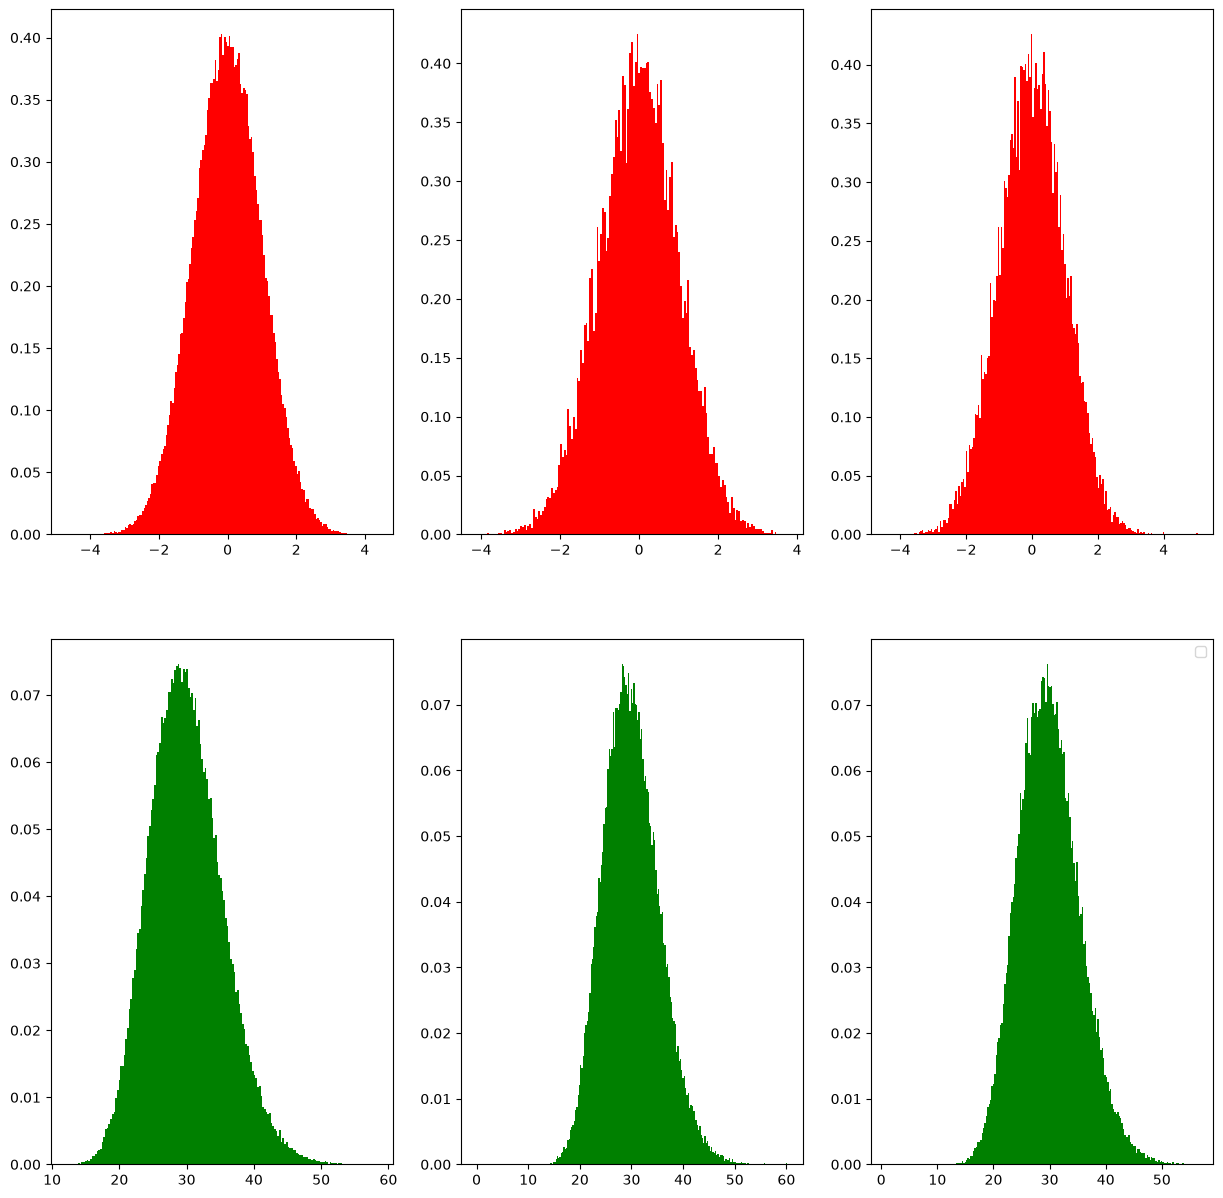

In [29]:
from functools import partial

distribs = [
    scipy.stats.norm(loc = 0, scale = 1), 
    scipy.stats.gamma(a = 30), 
] 

z0, z1, size, scale_lambda = 0, 1, 200000, 2 

def proposed_fn(z):
    return z + np.random.normal() * 10  

def scale_log_fn(fn, x): 
    return np.log(scale_lambda) + fn(x)

colors = ['red', 'green', 'blue']
fig, axes = plt.subplots(len(distribs), 3, squeeze=False, figsize = (15, 15))
for i in range(len(distribs)):
    axes[i, 0].hist(distribs[i].rvs(size = size), bins = 'auto', density = True, color = colors[i])
    axes[i, 1].hist(mcmc(z0, distribs[i].logpdf, proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    axes[i, 2].hist(mcmc(z1, partial(scale_log_fn, distribs[i].logpdf), proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    
plt.legend()
plt.show()

### Part 2: Tracking a position in 2D space 

The problem is to track the location distibution of a point in 2D array with 3 radars measure the Euclidean to the truth position
with some predefined deviation. 

Define $gamma$ as the posterior distribution of the point location after incoporate with radars measurement:  

$
   gamma(state) \propto prior(state) * \prod_1^3 p({measure_i} | {state})
$

with subtle assumption that each measure is independent for all radars. 

As the measure for radar_i has deviation sd, it means that ${measure_i}$ ~ $ N({measure_i}, ||radar_i - state|| , sd_i ^ 2)$ 

We could use this gamma function as the function used ratio for state transitioning.  

In [30]:
import math 
from scipy import stats 

def proposed_state(state):
    return state + np.random.normal(0, scale = move_sigmas)

# let start with gamma with no prior 
def gamma_pdf_fn(state, radar_measures): 
    log_sum = 0 
    state_measures = np.linalg.norm(radar_locs - state, axis = 1) 
    for radar_id in range(len(radar_measures)):
        log_sum += stats.norm(
            loc = state_measures[radar_id], 
            scale = radar_sigmas[radar_id]
        ).logpdf(radar_measures[radar_id])
    
    return log_sum 



In [83]:
# set up
# unknown to us 
pos_truth = np.array([1,1]) 

# radar positions
radar_locs = [
    np.array([0, 0]), 
    np.array([10, 10]), 
    np.array([6, 3])
]

# the deviations of the measurements for each radars 
radar_sigmas = np.array([
    0.5, 
    0.1, 
    0.1 
])

# move sigma 
move_sigmas = np.array(
    [
        0.6, 
        0.3
    ]
)

### Set up radar measures and running MCMC 

In [84]:
from functools import partial 

initial_state = np.array([2, 4])

# measure by radar with noise 
radar_measures = np.linalg.norm(radar_locs - pos_truth, axis=1) + np.random.normal(loc = 0, scale = radar_sigmas)
print("radars measure: ", radar_measures)

tracker = AcceptanceTracker() 
state_list = mcmc(initial_state, partial(gamma_pdf_fn, radar_measures = radar_measures), proposed_state, 20000, tracker)
print("acceptance rate: {}".format(tracker.get_acceptance_rate()))

radars measure:  [ 0.96323247 12.62109959  5.35965073]
acceptance rate: 0.1334


### Plot x and y distributions

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_28200/2286343919.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


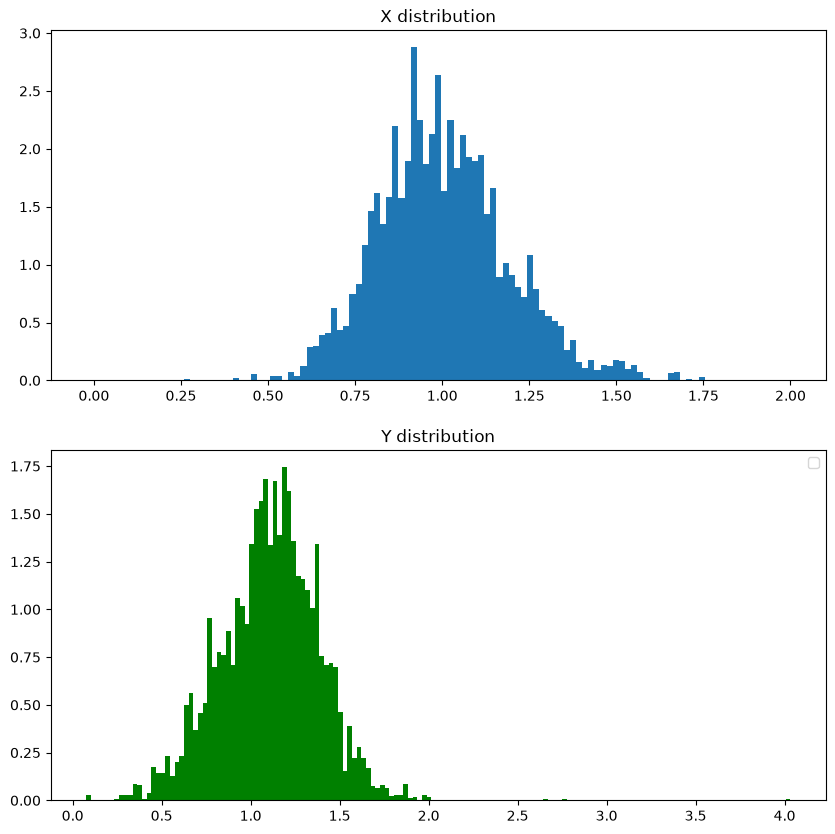

In [87]:
fig, ax = plt.subplots(2, 1, figsize = (10,10))
x = [state[0] for state in state_list]
y = [state[1] for state in state_list]

ax[0].hist(x, density = True, bins = 'auto')
ax[0].set_title("X distribution")

ax[1].hist(y, density = True, bins = 'auto', color = 'green')
ax[1].set_title("Y distribution")

plt.legend()
plt.show()

### Trace Plot 


/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_28200/3149738548.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


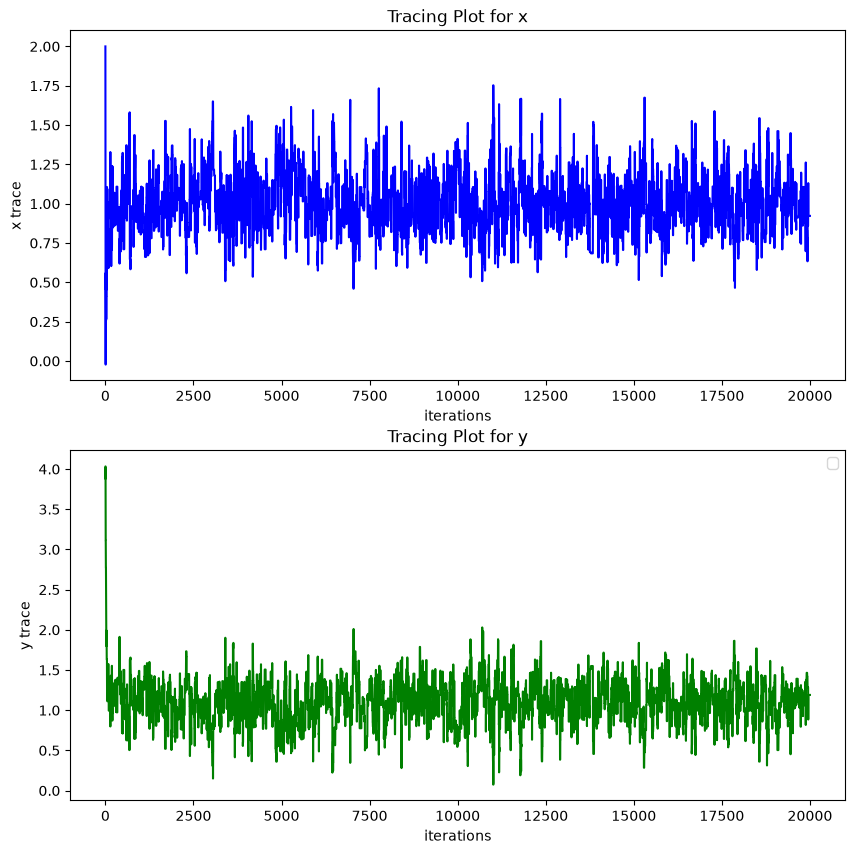

In [86]:
fig, ax = plt.subplots(2, 1, figsize = (10, 10)) 

sample_interval = 1
iters = [_ for _ in range(0, len(state_list), sample_interval)]
sample_x_list = [state_list[i][0] for i in range(0, len(state_list), sample_interval)]
sample_y_list = [state_list[i][1] for i in range(0, len(state_list), sample_interval)]

ax[0].plot(iters, sample_x_list, color = 'blue')
ax[0].set_xlabel("iterations")
ax[0].set_ylabel("x trace")
ax[0].set_title("Tracing Plot for x")

ax[1].plot(iters, sample_y_list, color = 'green')
ax[1].set_xlabel("iterations")
ax[1].set_ylabel("y trace")
ax[1].set_title("Tracing Plot for y")

plt.legend()
plt.show()

#### TODO 
[x] Experiment with predefined prior for the state. Currently there is no "prior" 

[x] Tracking acceptance rate track and experiment with higher move_sigmas. 

[x] MCMC trace plot. 

## Simulated Tempering 

A method that is helping with sampling a posterior distribution which has multiple modes by constructing a list of intermediate distributions $\pi_0, \pi_1, ... \pi_T$, applying the MCMC for each pair of distributions, 

### Problem with MCMC

- Given a pdf function:
$p(x) = 0.5 N(x; -5, 1) + 0.5 N(x; 5; 1)$

- Let's first visualize its pdf function.

    - As could be seen below, there are 2 modes for the distributions  

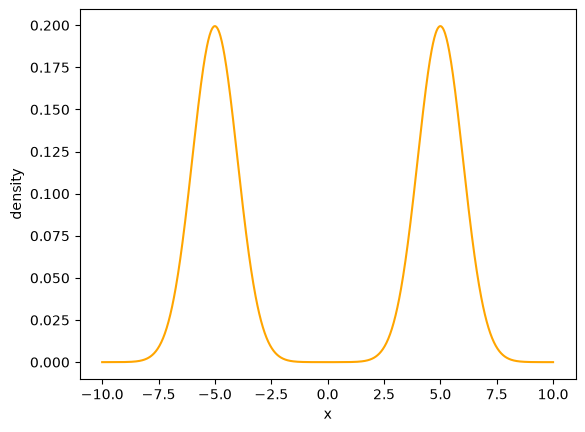

In [25]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns 

def pi_1_log_pdf(x):
    dist_0 = norm(loc = -5, scale = 1) 
    dist_1 = norm(loc = 5, scale = 1) 
    return np.logaddexp(
        np.log(0.5) + dist_0.logpdf(x), 
        np.log(0.5) + dist_1.logpdf(x),  
    )

x = np.linspace(-10, 10, 1000)
y = pi_1_log_pdf(x)

fig, ax =  plt.subplots()
ax.plot(x, np.exp(y), color = 'orange')
ax.set_xlabel("x")
ax.set_ylabel("density")
plt.show()

Now let's try to use normal MCMC methods to see how our sample looks like.

Let's start with z0 = 1. 

In [ ]:
def proposed_fn(z):
    return z + np.random.normal() * 3

z0, iters = 1, 20000 
tracker = AcceptanceTracker()
z_list = mcmc(z0, pi_1_log_pdf, proposed_fn, iters, tracker)
print("Acceptance rate: {}".format(tracker.get_acceptance_rate()))

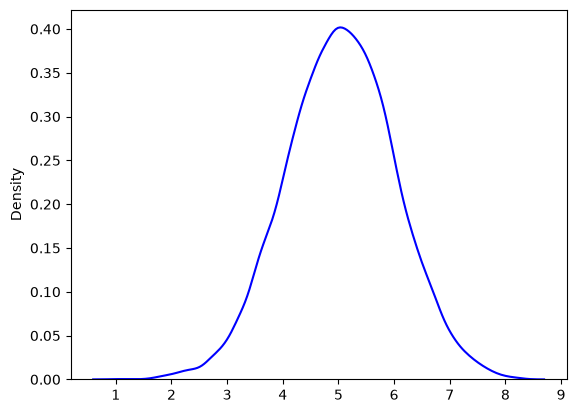

In [31]:
fig, ax =  plt.subplots()
sns.kdeplot(z_list, color = 'blue', ax = ax)
plt.show()

As could be seen, it seems that only the mode center around 5 is discovered. The other mode failed to be seen from our MCMC

Now let's try with the simulated tempering algorithm. 

In [57]:
from tqdm import trange
import numpy as np

class SimulatedTempering(object):
    def __init__(self, target_dist, target_sample, proposed_fn):
        # with the first dist is the target distrib, 
        # last dist is the initial distrib
        # store the logpdf func of the distribs 
        self._inter_dists = [target_dist]
        self._inter_samples = [ [target_sample] ]
        self._proposed_fn = proposed_fn 

    def add_intermediate_dist(self, dist, dist_sample):
        self._inter_dists.append(dist)
        self._inter_samples.append([dist_sample])

    def run(self, iters = 10000):
        for iter in trange(iters):
            for i in range(len(self._inter_dists) - 1, 0, -1):
                # mcmc for both i-1, i distribs 
                dist_i, dist_j = self._inter_dists[i], self._inter_dists[i-1]
                z_i_proposed, z_i_old = self._proposed_fn(self._inter_samples[i][-1]), self._inter_samples[i][-1]
                z_j_proposed, z_j_old = self._proposed_fn(self._inter_samples[i-1][-1]), self._inter_samples[i-1][-1]
                
                z_i_new = z_i_proposed if (np.log(np.random.uniform()) <= min(0, dist_i(z_i_proposed) - dist_i(z_i_old))) else z_i_old
                z_j_new = z_j_proposed if (np.log(np.random.uniform()) <= min(0, dist_j(z_j_proposed) - dist_j(z_j_old))) else z_j_old

                # swap between 2 distribs 
                log_ratio_new = dist_i(z_j_new) + dist_j(z_i_new)
                log_ratio_old = dist_i(z_i_new) + dist_j(z_j_new)
                if np.log(np.random.uniform()) <= min(log_ratio_new - log_ratio_old, 0): 
                    z_i_new, z_j_new = z_j_new, z_i_new
                
                self._inter_samples[i].append(z_i_new)
                self._inter_samples[i-1].append(z_j_new)
                
    
    def get_target_samples(self):
        return self._inter_samples[0]

Now try to see if our ST could help discover the other modes. 
In our experiment here we only experiment with a single intermediate distributions besides the target distribution. 
For sake of simplicity we choose normal distribution 

In [ ]:
from scipy.stats import norm 

solver = SimulatedTempering(
    pi_1_log_pdf, 
    z0, 
    proposed_fn
)

solver.add_intermediate_dist(
    norm(loc = 0, scale = 1).logpdf, 
    1
)

solver.run(iters = 10000)

In [ ]:
fig, ax =  plt.subplots()
z_list = solver.get_target_samples()
sns.kdeplot(z_list, color = 'blue', ax = ax)
ax.plot(x, np.exp(y), color = 'orange')
plt.show()